# TinyML en Producción: Compresión Extrema con emlearn y blackbox2c



[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/casos_de_estudio/tinyml_compresion_modelos.ipynb)




## Objetivos del Caso de Estudio


- **Perspectiva de Hardware:** Comprender las severas restricciones del *Edge Computing* (Microcontroladores *Bare-Metal* con < 32 KB de memoria Flash y sin sistema operativo).
- **Perspectiva de Ingeniería:** Contrastar la exportación directa de modelos (`emlearn`) frente a la Destilación de Conocimiento mediante modelos *Surrogate* (`blackbox2c`).
- **Implementación Transparente:** Instalar compiladores cruzados (`avr-gcc`, `arm-none-eabi-gcc`) en el entorno Python para compilar y medir el tamaño real del código C generado en tiempo de ejecución.
- **Criterio de Negocio:** Utilizar el Análisis de Sensibilidad de Características para reducir el *Bill of Materials* (BOM) del hardware físico.



## Prerrequisitos


- Entendimiento de modelos basados en árboles (Random Forest).
- Familiaridad básica con el concepto de compilación en C/C++.
- Haber completado: [Ensamblado de Modelos: Bagging y Boosting](../03_machine_learning/08_ensamblado_de_modelos.ipynb).

---



## Configuración del Entorno



Para que este notebook sea una simulación real de un entorno de desarrollo embebido, no solo instalamos librerías de Python, sino que **instalamos los compiladores de C para Arduino (AVR) y ARM Cortex-M** directamente en el sistema operativo subyacente de Colab/Linux.

> **NOTA**: para ejecución local, decidir manualmente qué instalar...

In [1]:
# @title *Esta celda configura el entorno Python y los compiladores del sistema*
import sys
import os
import subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Configurando entorno en Google Colab...")
    # 1. Clonamos el repositorio para utilidades
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

    # 2. Instalamos librerías de Python (TinyML)
    print("Instalando librerías Python (blackbox2c, emlearn)...")
    subprocess.run(["pip", "install", "-q", "blackbox2c", "emlearn", "xgboost"], check=True)

    # 3. Instalamos los compiladores cruzados en el SO (Linux)
    print("Instalando toolchains de C (avr-gcc, arm-none-eabi-gcc)... Esto tomará un minuto.")
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(["apt-get", "install", "-y", "-qq", "gcc-avr", "binutils-avr", "avr-libc", "gcc-arm-none-eabi"], check=True)
    print("¡Entorno TinyML listo!")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

Configurando entorno en Google Colab...
Instalando librerías Python (blackbox2c, emlearn)...
Instalando toolchains de C (avr-gcc, arm-none-eabi-gcc)... Esto tomará un minuto.
¡Entorno TinyML listo!


## 1. Introducción: El Reto del TinyML


En el desarrollo tradicional, si el modelo de Machine Learning pesa 500 MB, simplemente se alquila un servidor más grande, con capacidades para soportarlo. En el mundo del **TinyML** (Machine Learning en microcontroladores), las reglas de la física y la economía son implacables.

Imaginemos que somos el Ingeniero de Firmware de una empresa de domótica. Queremos fabricar un detector inteligente de calidad del aire que clasifique si en una habitación hay alguien durmiendo, cocinando, limpiando o si hay humo.
Para que el producto sea barato y la batería dure años, el equipo de hardware ha elegido el microcontrolador **ATmega328P** (el cerebro del Arduino Uno).

**Las Restricciones:**
- **Memoria Flash (ROM):** 32 KB en total (y el programa principal ya ocupa 15 KB). Presupuesto para el modelo de IA: **< 5 KB**.
- **Memoria RAM:** 2 KB.
- **FPU:** No tiene Unidad de Coma Flotante por hardware (las operaciones con decimales son lentas).

¿Cómo "metemos" un modelo predictivo de alta precisión en un espacio tan minúsculo?

## 2. Fase 1: El Modelo "Teacher" (El Mundo Ideal)


Primero, vamos a cargar nuestro dataset de sensores de gas (ADL) y entrenamos el mejor modelo posible en Python, sin preocuparnos por la memoria. Este será nuestro modelo "Maestro" (*Teacher*).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Carga de datos (Air Quality ADL Dataset)
dataset_path = "datasets/adl/datos_adl.csv"
df = load_dataset(dataset_path)

target_col = "Situacion"
sensor_cols =[c for c in df.columns if c != target_col]
class_names = ["Normal", "Cocinando", "Humo", "Limpiando"]

X = df[sensor_cols].values.astype(np.float32) # Usamos float32 por compatibilidad en C
y = (df[target_col].values - 1).astype(np.int32) # Clases de 0 a 3

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# 2. Entrenamos un Random Forest robusto (200 árboles)
rf_teacher = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
rf_teacher.fit(X_train, y_train)

acc_teacher = accuracy_score(y_test, rf_teacher.predict(X_test))
print(f"Accuracy del Modelo Teacher (Python): {acc_teacher*100:.2f}%")
print(f"Número total de nodos en el bosque: {sum(t.tree_.node_count for t in rf_teacher.estimators_)}")

Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/adl/datos_adl.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 1845 filas y 7 columnas.
Accuracy del Modelo Teacher (Python): 96.75%
Número total de nodos en el bosque: 41370



Tenemos un modelo excelente (`~96,7%` de precisión), pero es un monstruo matemático compuesto por más de `40.000` nodos de decisión.

## 3. Fase 2: El Enfoque Tradicional (`emlearn`)


El enfoque más directo para llevar esto al microcontrolador es usar una librería de transpilación como `emlearn`.  
**Concepto:** `emlearn` lee los 200 árboles de Python y escribe 200 árboles equivalentes en código C. Mantiene la arquitectura original intacta.

Vamos a exportarlo y, para ser rigurosos, **compilamos el código C generado en vivo** para medir cuántos bytes ocupa realmente en la memoria Flash (la sección `.text` del binario).

In [3]:
import emlearn
import tempfile

# Función auxiliar de ingeniería para compilar C y medir el tamaño en bytes
def medir_tamanio_flash(codigo_c, toolchain="avr"):
    gcc = "avr-gcc" if toolchain == "avr" else "arm-none-eabi-gcc"
    size_tool = "avr-size" if toolchain == "avr" else "arm-none-eabi-size"
    flags =["-mmcu=atmega328p", "-O2", "-std=c99"] if toolchain == "avr" else["-mcpu=cortex-m0", "-mthumb", "-O2", "-std=c99"]

    with tempfile.TemporaryDirectory() as td:
        src = os.path.join(td, "modelo.c")
        obj = os.path.join(td, "modelo.o")
        with open(src, "w", encoding="utf-8") as f:
            f.write(codigo_c)
        try:
            # Compilamos
            subprocess.run([gcc] + flags +["-c", src, "-o", obj], check=True, capture_output=True)
            # Medimos
            s = subprocess.run([size_tool, obj], capture_output=True, text=True, check=True)
            # Parseamos la salida de 'size' (la sección .text es la memoria Flash)
            lineas = s.stdout.strip().splitlines()
            return int(lineas[1].split()[0])
        except Exception as e:
            return f"Error de compilación: {e}"

# 1. Exportamos el Random Forest con emlearn
print("Exportando modelo con emlearn...")
cmodel = emlearn.convert(rf_teacher, method="inline")
codigo_emlearn = cmodel.save(name="emlearn_rf", file=None)

# Añadimos cabeceras estándar para que compile de forma aislada
codigo_emlearn_completo = "#include <stdint.h>\n#include <stddef.h>\n" + codigo_emlearn

# 2. Medimos el tamaño real en el silicio
flash_avr_emlearn = medir_tamanio_flash(codigo_emlearn_completo, "avr")
flash_arm_emlearn = medir_tamanio_flash(codigo_emlearn_completo, "arm")

print(f"Tamaño en Flash (Arduino ATmega328P): {flash_avr_emlearn / 1024:.2f} KB")
print(f"Tamaño en Flash (ARM Cortex-M0):      {flash_arm_emlearn / 1024:.2f} KB")

Exportando modelo con emlearn...
Tamaño en Flash (Arduino ATmega328P): 261.00 KB
Tamaño en Flash (ARM Cortex-M0):      252.00 KB


**⚠️ Fallo de Ingeniería (*Out of Memory*):**  
El código generado ocupa más de **250 KB**. Nuestro Arduino solo tiene 32 KB en total. El enfoque tradicional de exportar el modelo `1:1` ha fracasado.

> Lo siguiente a realizar por este camino... sería iterar una y otra vez sobre la complejidad de este modelo (o alguno compatible con `emblearn`), hasta dar con "algo" que "entre" en nuestro hardware de destino.

## 4. Fase 3: El Cambio de Paradigma (`blackbox2c`)


Si no podemos meter 200 árboles en el chip, ¿qué hacemos?
La solución es la **Destilación de Conocimiento** (*Knowledge Distillation*). En lugar de exportar el bosque, entrenamos un único árbol de decisión muy pequeño (el *Student* o *Surrogate*) para que imite el comportamiento del bosque gigante (el *Teacher*).

Para esto utilizamos `blackbox2c`, una librería diseñada específicamente para generar código C ultra-compacto sin dependencias.

> **NOTA**: `blackbox2c` opera de igual manera sobre cualquier modelo de `scikit-learn`. Tanto para tareas de clasificación como de regresión.

### Análisis de Sensibilidad (Reduciendo el Costo de Fabricación)


Antes de compilar, un Ingeniero de Hardware nos hace una pregunta: *"Cada sensor MQ cuesta `$1,20`. Si fabricamos `10.000` unidades, son `$12.000` por sensor. ¿Realmente necesitamos los 6 sensores?"*

`blackbox2c` incluye un analizador de sensibilidad que evalúa el modelo de "caja negra" para decirnos qué sensores son redundantes.

In [ ]:
from blackbox2c.analysis import FeatureSensitivityAnalyzer

print("Analizando sensibilidad de los sensores de hardware...")
analyzer = FeatureSensitivityAnalyzer(n_repeats=10, random_state=42)
resultados_analisis = analyzer.analyze(rf_teacher, X_train, y_train, feature_names=sensor_cols)

print(resultados_analisis.summary())

# Obtenemos los sensores redundantes (impacto < 5%)
redundantes = resultados_analisis.get_redundant_features(threshold=0.05)
print(f"\nSensores candidatos a eliminar del diseño físico: {[sensor_cols[i] for i in redundantes]}")

Analizando sensibilidad de los sensores de hardware...
Feature Sensitivity Analysis
Feature 4 (MQ138): Impact = 0.1812 ± 0.0054 (Medium)
Feature 5 (MG-811): Impact = 0.1421 ± 0.0077 (Medium)
Feature 3 (MQ137): Impact = 0.1283 ± 0.0053 (Medium)
Feature 1 (MQ9): Impact = 0.0720 ± 0.0069 (Medium)
Feature 2 (MQ135): Impact = 0.0683 ± 0.0044 (Medium)
Feature 0 (MQ2): Impact = 0.0251 ± 0.0020 (Low)

Recommendations:
- 5 feature(s) have moderate impact

Sensores candidatos a eliminar del diseño físico: ['MQ2']


Gráficamente se vería como:

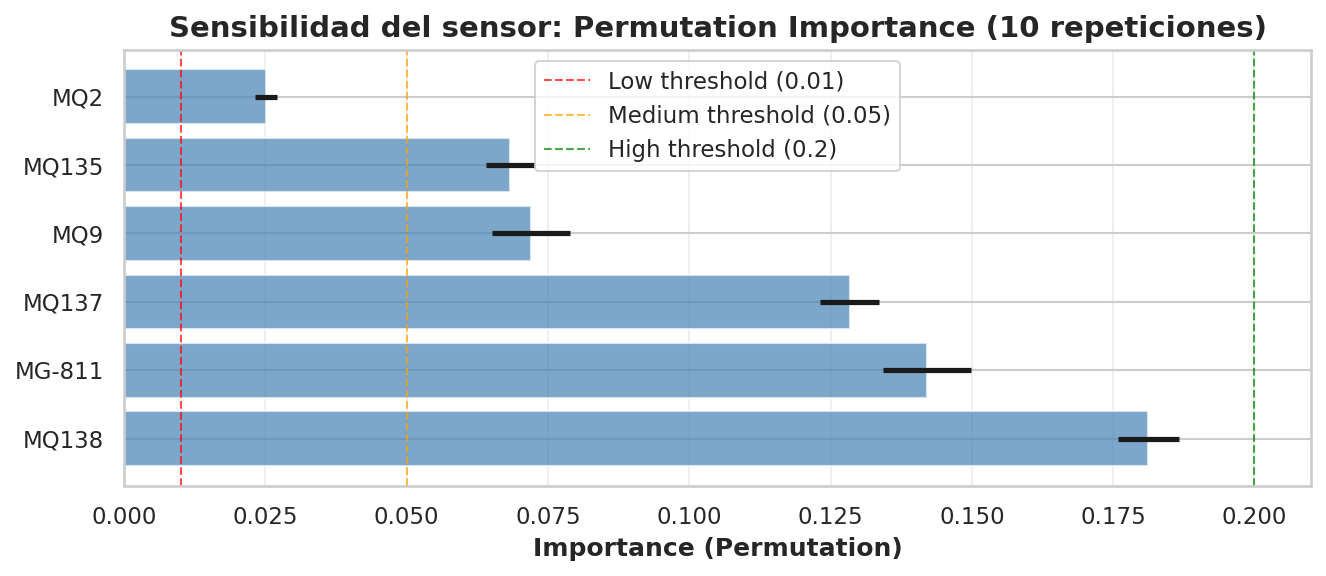

In [5]:
fig, ax = resultados_analisis.plot(figsize=(9, 4))
ax.set_title("Sensibilidad del sensor: Permutation Importance (10 repeticiones)")
plt.tight_layout()
plt.show()

**Decisión de Negocio:** El sensor `MQ2` tiene un impacto casi nulo en la predicción. Al eliminarlo del diseño del circuito impreso (PCB), acabamos de ahorrarle a la empresa **`$12.000 anuales`** en costos de fabricación (BOM - *Bill of Materials*).

## 5. Extracción del Surrogate y Benchmarking Extremo


Ahora, vamos a extraer el modelo *Surrogate*. Le decimos a `blackbox2c` que el árbol no puede tener una profundidad mayor a 6 (`max_depth=6`). Esto garantiza matemáticamente que el código generado será minúsculo.

A fines comparativos, usamos exactamente el mismo modelo que con `emlearn`:

In [ ]:
from blackbox2c import Converter, ConversionConfig
from sklearn.metrics import f1_score

# 1. Configuramos el conversor con un presupuesto estricto
config = ConversionConfig(
    function_name="detectar_actividad",
    max_depth=6,             # Límite estricto de profundidad
    optimize_rules="medium", # Poda ramas redundantes
    precision=8              # Precisión de 8-bits
)

converter = Converter(config)

# 2. Extraemos el Surrogate y generamos el código C
print("\nExtrayendo modelo Surrogate y generando código C...")
codigo_blackbox = converter.convert(
    model=rf_teacher,
    X_train=X_train,
    X_test=X_test,
    feature_names=sensor_cols,
    class_names=class_names
)

# Añadimos cabecera para compilación (en realidad no es necesario, blackbox2x entrega código listo para compilar)
codigo_blackbox_completo = "#include <stdint.h>\n" + codigo_blackbox

# 3. Medimos el tamaño real en el silicio
flash_avr_bb = medir_tamanio_flash(codigo_blackbox_completo, "avr")
flash_arm_bb = medir_tamanio_flash(codigo_blackbox_completo, "arm")

print(f"\n--- Resultados de Compresión Extrema ---")
print(f"Tamaño en Flash (Arduino ATmega328P): {flash_avr_bb} Bytes ({(flash_avr_bb/1024):.2f} KB)")
print(f"Tamaño en Flash (ARM Cortex-M0):      {flash_arm_bb} Bytes ({(flash_arm_bb/1024):.2f} KB)")

# 4. Evaluamos la Fidelidad (¿Qué tanto se parece al Teacher?)
metricas = converter.get_metrics()
print(f"\nFidelidad del Surrogate respecto al Teacher: {metricas['fidelity']*100:.2f}%")

# Calculamos el F1-Score real del Surrogate en el Test Set
y_pred_surrogate = converter.surrogate_tree_.predict(X_test)
f1_surrogate = f1_score(y_test, y_pred_surrogate, average='weighted')
print(f"F1-Score del Surrogate en Producción: {f1_surrogate*100:.2f}%")


Extrayendo modelo Surrogate y generando código C...

Starting conversion for model: RandomForestClassifier
  Task: Classification, Features: 6, Classes: 4, Max depth: 6

[1/4] Extracting surrogate decision tree...
  Surrogate fidelity: 0.9372

[2/4] Optimizing decision rules...
  Nodes: 125, Leaves: 77, Depth: 6

[3/4] Generating C code...

[4/4] Estimating code size...
  Estimated FLASH: 934 bytes, RAM: 32 bytes

[OK] Conversion complete!

--- Resultados de Compresión Extrema ---
Tamaño en Flash (Arduino ATmega328P): 1220 Bytes (1.19 KB)
Tamaño en Flash (ARM Cortex-M0):      740 Bytes (0.72 KB)

Fidelidad del Surrogate respecto al Teacher: 93.72%
F1-Score del Surrogate en Producción: 90.77%


### El Triunfo de la Ingeniería


¡Pasamos de **261.000 Bytes** a apenas **~1.000 Bytes**! Es una reducción de tamaño de más de **260x**.
El modelo ahora entra perfectamente en el Arduino, dejando 31 KB libres para el resto del programa. A cambio, solo sacrificamos un `~3%` de precisión (*Fidelity* > 93%). En ingeniería de sistemas embebidos, este es un intercambio (*trade-off*) absolutamente ganador.

Veamos cómo luce el código C generado. Es una función `if-else` pura, sin bucles, sin memoria dinámica (`malloc`) y sin dependencias de librerías externas.

In [10]:
# Mostramos las primeras 50 líneas del código generado
print("\n".join(codigo_blackbox.splitlines()[:50]) + "\n    // ... (código truncado para visualización) ...\n}")

/*
 * Auto-generated C code by BlackBox2C
 *
 * Model Information:
 *   - Input features: 6
 *   *   - Output classes: 4
 *   - Precision: 8-bit
 *   - Fixed-point: No
 *
 * This code is optimized for embedded systems with limited resources.
 */

#include <stdint.h>


/* Class labels */
#define NORMAL 0
#define COCINANDO 1
#define HUMO 2
#define LIMPIANDO 3


/* Prediction function */
uint8_t detectar_actividad(float features[6]) {
    if (features[4] <= 1352.660522f) {
        if (features[2] <= 1015.779266f) {
            if (features[0] <= 573.098358f) {
                if (features[2] <= 999.137756f) {
                    if (features[0] <= 476.820877f) {
                        return 0;
                    } else {
                        return 0;
                    }
                } else {
                    if (features[1] <= 556.249451f) {
                        if (features[0] <= 517.696075f) {
                            return 0;
                        } else {
     

## 6. Exportación Multi-Plataforma (Arduino y MicroPython)



`blackbox2c` no solo genera C genérico. Tiene exportadores nativos que aplican optimizaciones específicas para cada plataforma.

Por ejemplo, en **Arduino**, la memoria RAM es de solo 2 KB. Si guardamos los nombres de las clases ("Normal", "Humo") en variables normales, consumirán RAM. El `ArduinoExporter` utiliza la directiva `PROGMEM` para forzar que esos *strings* se guarden en la memoria Flash, salvando valiosa RAM.



In [13]:
from blackbox2c.exporters import ArduinoExporter, MicroPythonExporter

# Exportación para Arduino (con PROGMEM)
ard_exporter = ArduinoExporter(function_name="detectar_actividad", use_progmem=True)
codigo_arduino = ard_exporter.generate(converter.surrogate_tree_, feature_names=sensor_cols, class_names=class_names)

print("=== Fragmento de Código Arduino (.ino) ===")
print("\n".join(codigo_arduino.splitlines()[15:30]) + "\n// ...")

# Exportación para MicroPython (ESP32 / Raspberry Pi Pico)
mp_exporter = MicroPythonExporter(function_name="detectar_actividad", class_name="DetectorAire", use_const=True)
codigo_mp = mp_exporter.generate(converter.surrogate_tree_, feature_names=sensor_cols, class_names=class_names)

print("\n=== Fragmento de Código MicroPython (.py) ===")
print("\n".join(codigo_mp.splitlines()[10:25]) + "\n# ...")

=== Fragmento de Código Arduino (.ino) ===
// Feature names
const char* const PROGMEM FEATURE_NAMES[] = {
    "MQ2",
    "MQ9",
    "MQ135",
    "MQ137",
    "MQ138",
    "MG-811",
};


// Class names
const char* const PROGMEM CLASS_NAMES[] = {
    "Normal",
    "Cocinando",
// ...

=== Fragmento de Código MicroPython (.py) ===
from micropython import const


class DetectorAire:
    """Decision tree predictor for classification."""
    
    # Feature names
    FEATURE_NAMES = ['MQ2', 'MQ9', 'MQ135', 'MQ137', 'MQ138', 'MG-811']
    
    # Class names
    CLASS_NAMES = ['Normal', 'Cocinando', 'Humo', 'Limpiando']

    @staticmethod
    def detectar_actividad(features):
        """
# ...


## 7. Consideraciones Avanzadas para Producción


### Latencia de Inferencia


El código generado es un árbol de profundidad 6. Esto significa que, en el peor de los casos, el microcontrolador solo hará **6 comparaciones lógicas (`if`)** para emitir una predicción.
Incluso en un Arduino a 16 MHz, esto toma **menos de 10 microsegundos**. Es órdenes de magnitud más rápido que el tiempo que tarda el sensor analógico en calentarse y leer el gas.



### Matriz de Decisión MLOps para el Edge


Como Ingeniero, ¿qué herramienta se elige para un proyecto de hardware?

| Escenario | Herramienta Recomendada | Justificación |
| :--- | :--- | :--- |
| **Redes Neuronales, Audio, Visión** | **TensorFlow Lite Micro (TFLM)** | Requiere un *runtime* pesado (>25 KB), pero es el único capaz de ejecutar convoluciones eficientemente usando aceleradores de hardware (CMSIS-NN). |
| **Modelos Clásicos, Memoria Holgada** | **emlearn / sklearn2c** | Exporta el modelo 1:1. Ideal si tenemos un chip grande (ej. ESP32 con 4MB Flash) y se necesita que el modelo en C sea matemáticamente idéntico al de Python por motivos regulatorios. |
| **Cajas Negras, Memoria Ultra-Restringida** | **blackbox2c** | Transforma cualquier modelo de `scikit-learn` en un *Surrogate* ultra-compacto (< 2 KB). Ideal para microcontroladores de 8-bits o cuando el firmware principal ya ocupa casi toda la memoria. |



## Conclusión


El despliegue en el *Edge* nos obliga a pensar más allá del *Accuracy*. Hemos demostrado cómo la **Destilación de Conocimiento** nos permite comprimir un modelo masivo en una función lógica pura, y cómo el **Análisis de Sensibilidad** impacta directamente en los costos de fabricación del hardware.

Con estas herramientas, estás listo para llevar la Inteligencia Artificial a los dispositivos más pequeños del planeta.

## Referencias


1. [Repositorio Oficial de BlackBox2C](https://github.com/AxelSkrauba/BlackBox2C)
2. [Repositorio Oficial de emlearn](https://github.com/emlearn/emlearn)
3. Warden, P., & Situnayake, D. (2020). *TinyML: Machine learning with TensorFlow Lite on Arduino and ultra-low-power microcontrollers*. O'Reilly Media.

---


## Entorno de Ejecución


In [14]:
from utils.environment import environment_table
environment_table(include_all=True)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
Cython,3.0.12
IPython,7.34.0
PIL,11.3.0
anywidget,0.9.21
argparse,1.1
backcall,0.2.0
blackbox2c,0.1.1
bottleneck,1.4.2
